In [2]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import seaborn as sns 
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [3]:
def load_answers(dir_path, dataset_name):
    # load all parquet files from the directory, stack them into a pandas datafame
    # this only reads the participant ID, ground trush answer and the prediction,
    # which is significantly (about 100x) faster than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings in some columns

    fpaths = list(dir_path.rglob("*.parquet"))

    dfs = []

    cols_to_read = [
        "ID",
        "ground_truth",
        "prediction",
        "generated_text",
        "finish_reason",
    ]

    for fpath in tqdm(fpaths):
        model = fpath.parent.name.split("-", 3)[-1]
        benchmark = fpath.parent.parent.name.split("_", 1)[-1].upper()

        df = pd.read_parquet(fpath, columns=cols_to_read)

        df = df.assign(model=model, benchmark=benchmark)

        df["correct"] = (df["ground_truth"] == df["prediction"]).astype(int)

        df["dataset"] = dataset_name

        dfs.append(df)

    return pd.concat(dfs)


tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")

def count_tokens(text):
    tokens = tokenizer.encode(text)

    return len(tokens)


In [4]:
nifd_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/NIFD')
nacc_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/nacc_test_updated')
adni_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/ADNI')
adni_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/PPMI')

In [5]:
nifd = load_answers(nifd_path,dataset_name='NIFD')
adni = load_answers(adni_path,dataset_name='ADNI')
nacc = load_answers(nacc_path,dataset_name='NACC')
ppmi = load_answers(nacc_path,dataset_name='PPMI')

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 72/72 [00:20<00:00,  3.50it/s]


In [6]:
model_order = [
    "Qwen2.5-3B-Instruct",
    "Qwen2.5-7B-Instruct",
    # "NACC-3B",
    "NACC-3B-OS",
    "NACC-3B-OS-SCE",
    # "NACC-3B-SCE",
    # "NACC-7B-OS",
    # "NACC-7B-OS-SCE",
]

In [7]:
df = pd.concat([nifd,adni,nacc,ppmi])

df = df[['dataset','benchmark','model','ID','generated_text','finish_reason','correct',]]

# only keep models we care about
df = df[df['model'].isin(model_order)]

In [8]:
df.sample(10)

,dataset,benchmark,model,ID,generated_text,finish_reason,correct
55165,PPMI,ETPR,NACC-3B-OS,NACC833217,"To identify the primary etiologic diagnosis, w...",stop,1
41449,NACC,ETPR,Qwen2.5-7B-Instruct,NACC306855,Let's analyze the information step by step to ...,stop,0
96240,NACC,ETPR,NACC-3B-OS-SCE,NACC219906,"Given the comprehensive patient record, there ...",stop,1
39691,PPMI,ETPR,NACC-3B-OS-SCE,NACC380067,The primary cause of cognitive decline associa...,stop,0
22961,PPMI,MCI,Qwen2.5-7B-Instruct,NACC162560,Let's break down the information and determine...,stop,0
98992,PPMI,COG,NACC-3B-OS-SCE,NACC850270,Based on the provided comprehensive evaluation...,stop,0
124994,NACC,COG,NACC-3B-OS,NACC051023,Let's analyze the information to provide a log...,stop,1
62241,PPMI,COG,Qwen2.5-3B-Instruct,NACC043349,To determine the cognitive status of the patie...,stop,0
126009,NACC,COG,Qwen2.5-3B-Instruct,NACC670110,"To determine the patient's cognitive status, l...",stop,1
108913,PPMI,COG,NACC-3B-OS,NACC269854,"First, let’s analyze the key factors given in ...",stop,1


In [9]:
# doing all 2M takes 35 minutes
_df = df.sample(50000).copy()
_df['tokens'] = _df['generated_text'].map(count_tokens)

In [10]:
_df = _df[_df['finish_reason']=='stop'].copy()
# _df = _df[_df['tokens']<4000].copy()

In [11]:
_df.sort_values('tokens')

,dataset,benchmark,model,ID,generated_text,finish_reason,correct,tokens
125609,PPMI,COG,NACC-3B-OS-SCE,NACC333823,The patient's cognitive status based on the pr...,stop,1,24
102803,NACC,COG,NACC-3B-OS-SCE,NACC507601,"Based on the information provided, the correct...",stop,1,26
109590,PPMI,ETPR,NACC-3B-OS-SCE,NACC479329,The main cause of the patient's cognitive impa...,stop,1,28
123049,NACC,ETPR,NACC-3B-OS-SCE,NACC017827,Given the patient’s extensive history and clin...,stop,1,28
91840,PPMI,COG,NACC-3B-OS-SCE,NACC615041,The final classification of the patient's cogn...,stop,0,33
...,...,...,...,...,...,...,...,...
4153,ADNI,COG,Qwen2.5-7B-Instruct,3970,To determine the patient's cognitive status ba...,stop,0,1047
12707,NACC,ETPR,Qwen2.5-3B-Instruct,NACC454662,To determine the primary etiology causing the ...,stop,0,1073
21615,PPMI,MCI,Qwen2.5-3B-Instruct,NACC579794,Let's break down the analysis for the subject'...,stop,0,1084
60400,NACC,COG,NACC-3B-OS,NACC282116,"To determine the patient's cognitive status, w...",stop,1,3191


In [160]:
# make all separate panels
# two factor anova with posthoc analysis

In [12]:
# df contains: tokens, model, dataset
_df["model"] = _df["model"].astype("category")
_df["dataset"] = _df["dataset"].astype("category")
_df["ood"] = (_df["dataset"] != "NACC").astype("category")
# _df["benchmark"] = _df["benchmark"].astype("category")

Text(0.5, 1.0, 'Correct answers are shorter')

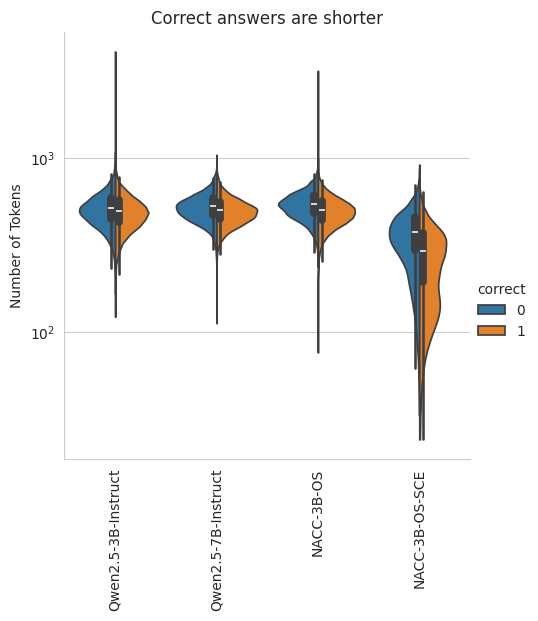

In [13]:
g = sns.catplot(
    _df,
    y='tokens',
    x='model',
    order=model_order,
    kind='violin',
    hue='correct',
    split=True,
    cut=0,
)

plt.yscale('log')
# g._legend.set_title('Out of dist.')

# plt.ylim(0,1200)
plt.ylabel('Number of Tokens')
plt.xlabel('')
plt.xticks(rotation=90)
plt.title('Correct answers are shorter')

([0, 1, 2, 3],
 [Text(0, 0, 'Qwen2.5-3B-Instruct'),
  Text(1, 0, 'Qwen2.5-7B-Instruct'),
  Text(2, 0, 'NACC-3B-OS'),
  Text(3, 0, 'NACC-3B-OS-SCE')])

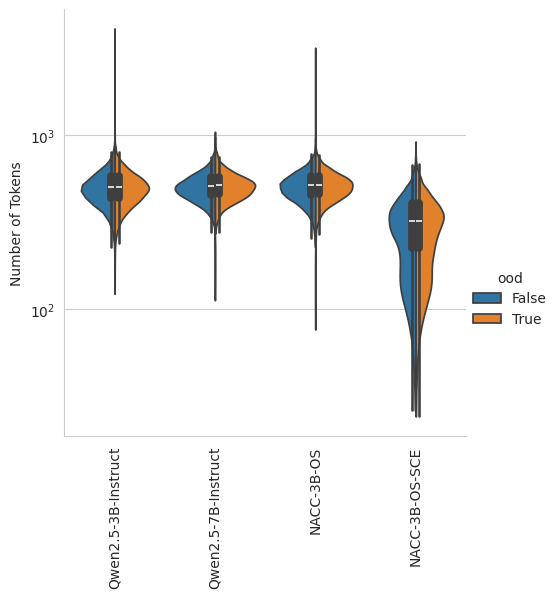

In [14]:
g = sns.catplot(
    _df,
    y='tokens',
    x='model',
    order=model_order,
    kind='violin',
    hue='ood',
    split=True,
    cut=0,
)

plt.yscale('log')
# g._legend.set_title('Out of dist.')

# plt.ylim(0,1200)
plt.ylabel('Number of Tokens')
plt.xlabel('')
plt.xticks(rotation=90)


In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# df contains: tokens, model, dataset
_df["model"] = _df["model"].astype("category")
_df["dataset"] = _df["dataset"].astype("category")
_df["ood"] = (_df["dataset"] != "NACC").astype("category")
# _df["benchmark"] = _df["benchmark"].astype("category")

# Two-way ANOVA with interaction
formula = "tokens ~ C(model) * C(correct)"
model_anova = smf.ols(formula, data=_df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)


                           sum_sq       df             F         PR(>F)
C(model)             3.913014e+08      3.0  10794.267102   0.000000e+00
C(correct)           2.488082e+07      1.0   2059.053841   0.000000e+00
C(model):C(correct)  8.720385e+06      3.0    240.556706  5.499270e-155
Residual             6.040600e+08  49990.0           NaN            NaN


In [16]:
# All pairwise comparisons
from statsmodels.stats.multicomp import pairwise_tukeyhsd

_df["group"] = _df["model"].astype(str) + "_" + _df["correct"].astype(str)

tukey = pairwise_tukeyhsd(endog=_df["tokens"],
                          groups=_df["group"],
                          alpha=0.05)
print(tukey.summary())

                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------
     NACC-3B-OS-SCE_0      NACC-3B-OS-SCE_1 -87.2772    0.0 -93.0999 -81.4545   True
     NACC-3B-OS-SCE_0          NACC-3B-OS_0 173.1185    0.0 166.4637 179.7732   True
     NACC-3B-OS-SCE_0          NACC-3B-OS_1 129.9584    0.0 124.1294 135.7874   True
     NACC-3B-OS-SCE_0 Qwen2.5-3B-Instruct_0 146.5923    0.0  140.378 152.8066   True
     NACC-3B-OS-SCE_0 Qwen2.5-3B-Instruct_1 127.2226    0.0  121.165 133.2802   True
     NACC-3B-OS-SCE_0 Qwen2.5-7B-Instruct_0 157.0022    0.0 149.1327 164.8717   True
     NACC-3B-OS-SCE_0 Qwen2.5-7B-Instruct_1 129.7393    0.0 122.5565 136.9221   True
     NACC-3B-OS-SCE_1          NACC-3B-OS_0 260.3957    0.0  254.587 266.2043   True
     NACC-3B-OS-SCE_1          NACC-3B-OS_1 217.2356    0.0  212.

In [17]:
# differences between models averaging over datasets

tukey_models = pairwise_tukeyhsd(endog=_df["tokens"],
                                 groups=_df["correct"],
                                 alpha=0.05)
print(tukey_models.summary())


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     0      1 -56.1958   0.0 -58.7405 -53.6512   True
-----------------------------------------------------


In [18]:
# differences between models averaging over datasets

tukey_models = pairwise_tukeyhsd(endog=_df["tokens"],
                                 groups=_df["model"],
                                 alpha=0.05)
print(tukey_models.summary())


               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
       group1              group2        meandiff p-adj    lower    upper   reject
----------------------------------------------------------------------------------
         NACC-3B-OS      NACC-3B-OS-SCE -202.1709    0.0 -205.5798 -198.762   True
         NACC-3B-OS Qwen2.5-3B-Instruct   -8.6552    0.0  -12.0674   -5.243   True
         NACC-3B-OS Qwen2.5-7B-Instruct   -3.6282 0.1345   -7.9429   0.6865  False
     NACC-3B-OS-SCE Qwen2.5-3B-Instruct  193.5157    0.0  190.1048 196.9266   True
     NACC-3B-OS-SCE Qwen2.5-7B-Instruct  198.5427    0.0   194.229 202.8564   True
Qwen2.5-3B-Instruct Qwen2.5-7B-Instruct     5.027 0.0147    0.7107   9.3433   True
----------------------------------------------------------------------------------


In [19]:
# differences between datasets averaging over models

tukey_datasets = pairwise_tukeyhsd(endog=_df["tokens"],
                                   groups=_df["ood"],
                                   alpha=0.05)
print(tukey_datasets.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 False   True   2.0425 0.1142 -0.4918 4.5769  False
---------------------------------------------------
